# Neural Signal Processing: From Raw Traces to Spike Train Statistics

Two linked explorations in signal processing, using a course-provided calcium-imaging-style
recording (`Neural_data.csv`, 50 Hz, baseline + stimulus) and a multi-neuron spike train
dataset (`spike_trains.csv`, 5 neurons x 100 trials, 1000 Hz binary spike bins).

**Part 1 - Signal fundamentals:** segmenting a recording into baseline/stimulus, manual
resampling, aliasing and the Nyquist limit, and minimum bit depth for a given resolution.

**Part 2 - Noise reduction:** SNR estimation via two methods, and comparing noise-reduction
strategies (block averaging, rectangular vs. triangular smoothing kernels).

**Part 3 - Spike train analysis:** firing rate, Fano Factor, inter-spike intervals, raster
plots, PSTHs, and auto-/cross-correlation, used together to characterize and compare the
firing style of five simulated neurons (Poisson-like, regular, and bursting).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

df = pd.read_csv('Neural_data.csv')
df3 = pd.read_csv('spike_trains.csv')

## Part 1 - Signal Fundamentals: Segmentation, Resampling, Aliasing, Quantization

**1.A - Baseline segment (0-9s).** The recording is split into a 0-9s noise-only baseline and a 12-30s stimulus segment (which contains both the response and noise), based on the 50 Hz sampling rate. Plotting the baseline alone:

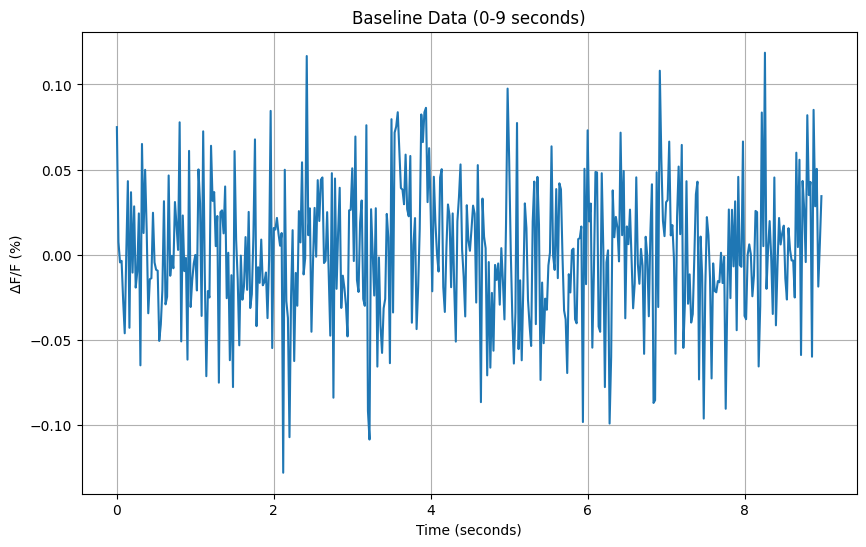

In [ ]:
# sampling rate
HZ = 50

#first 9 seconds as baseline (noise)
baseline_end_time = 9
baseline_df = df.iloc[0 : baseline_end_time * HZ]

#signal starting from 12 seconds (stimulus part)
stim_start_time = 12
stim_df = df.iloc[stim_start_time * HZ : ]

#time axis for plotting
def get_time_axis(data_frame, sampling_rate, start_offset=0):
    return (np.arange(len(data_frame)) / sampling_rate) + start_offset

#signals as numpy arrays
stim_signal = stim_df['ΔF/F (%)'].values   # signal + noise
noise_signal = baseline_df['ΔF/F (%)'].values  # noise only

plt.figure(figsize=(10, 6))
time_base = get_time_axis(baseline_df, HZ)
plt.plot(time_base, baseline_df['ΔF/F (%)'])
plt.title('Baseline Data (0-9 seconds)')
plt.xlabel('Time (seconds)')
plt.ylabel('ΔF/F (%)')
plt.grid(True)
plt.show()

**1.A - Stimulus segment (12-30s):**

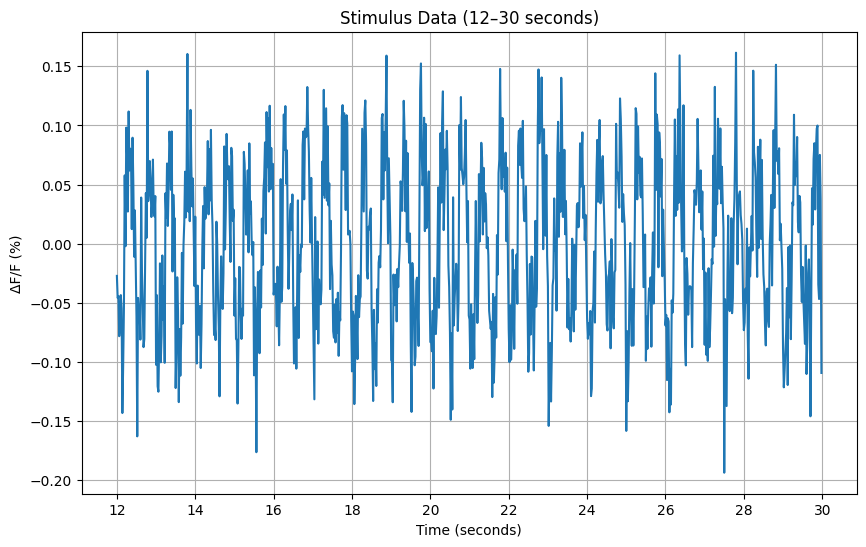

In [ ]:
time_stim = get_time_axis(stim_df, HZ, start_offset=stim_start_time)

plt.figure(figsize=(10, 6))
plt.plot(time_stim, stim_df['ΔF/F (%)'])
plt.title('Stimulus Data (12–30 seconds)')
plt.xlabel('Time (seconds)')
plt.ylabel('ΔF/F (%)')
plt.grid(True)
plt.xticks(np.arange(12, 31, 2))
plt.show()

**1.A - Full signal (0-30s),** showing both segments together for direct comparison:

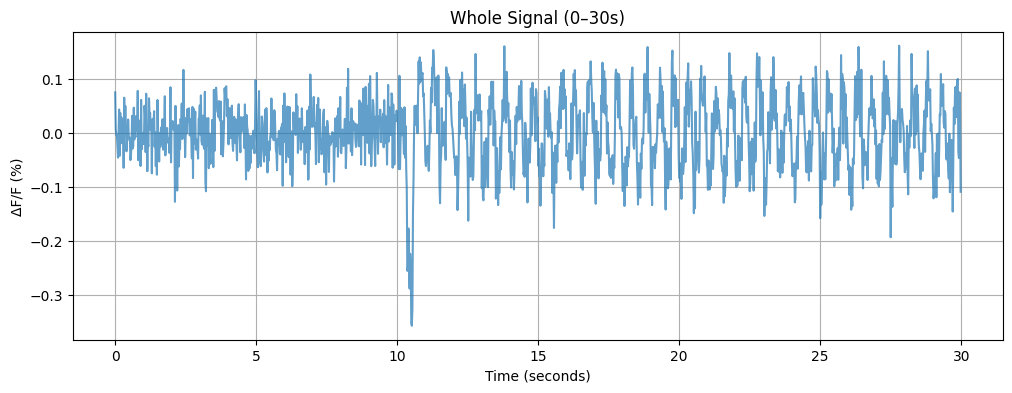

In [ ]:
time_full = get_time_axis(df, HZ)

plt.figure(figsize=(12, 4))
plt.plot(time_full, df['ΔF/F (%)'], alpha=0.7)
plt.title('Whole Signal (0–30s)')
plt.xlabel('Time (seconds)')
plt.ylabel('ΔF/F (%)')
plt.grid(True)
plt.show()

**1.B - Manual resampling.** The stimulus segment is manually downsampled to 25 Hz, 10 Hz, and ~3.33 Hz by taking every *k*-th sample (`step = round(50 / target_freq)`), rebuilding a matching time axis for each new rate.

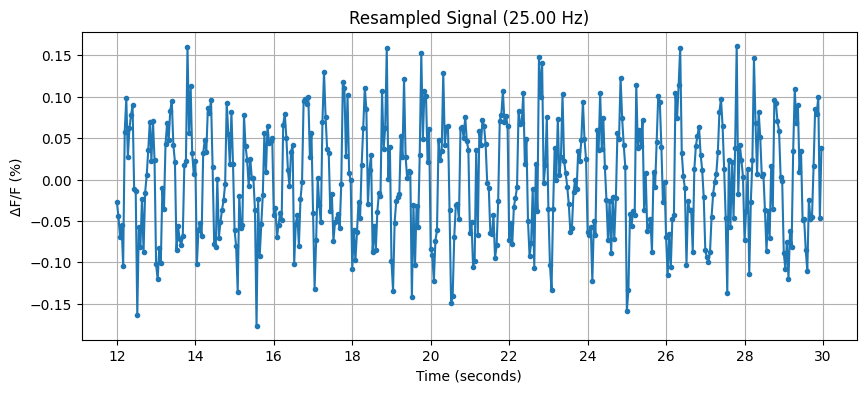

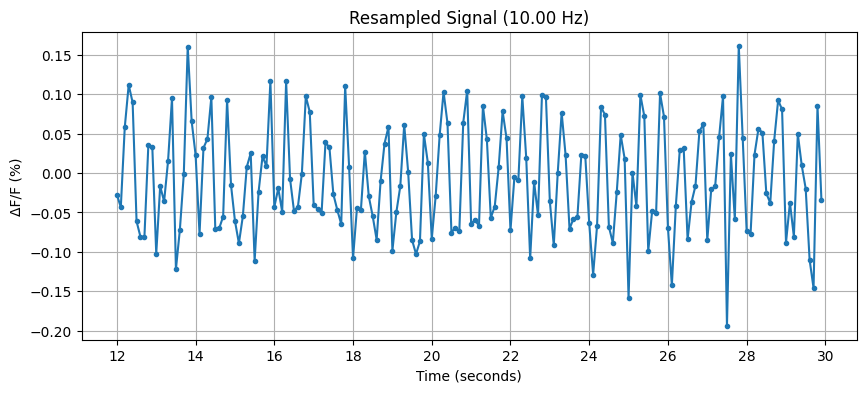

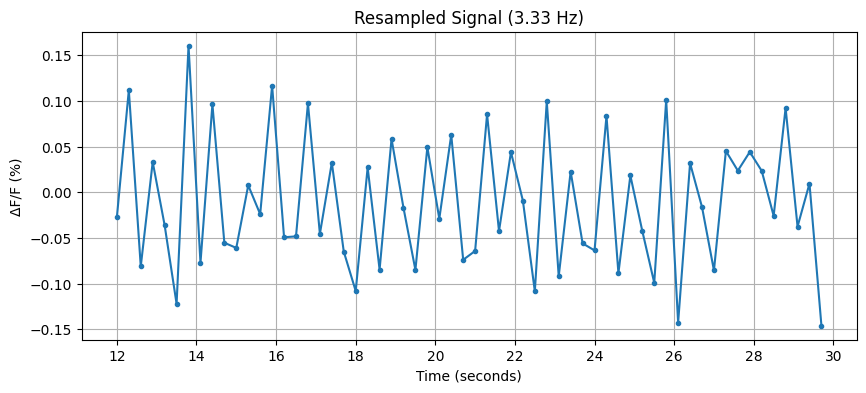

In [ ]:
#target sampling frequencies
target_frequencies = [25, 10, 3.33]

# use only the stimulus part
stimulus_part = stim_signal

for f_new in target_frequencies:

    # calculate step size (how many samples to skip)
    step = round(HZ / f_new)

    # actual sampling rate after rounding
    actual_fs = HZ / step

    # downsample by taking every 'step'
    resampled_data = stimulus_part[::step]

    # create new time axis
    time_resampled = np.arange(len(resampled_data)) / actual_fs + stim_start_time

    # plot the resampled signal
    plt.figure(figsize=(10, 4))
    plt.plot(time_resampled, resampled_data, 'o-', markersize=3)

    plt.title(f'Resampled Signal ({actual_fs:.2f} Hz)')
    plt.xlabel('Time (seconds)')
    plt.ylabel('ΔF/F (%)')
    plt.grid(True)
    plt.xticks(np.arange(12, 31, 2))

    plt.show()

**1.C - Aliasing and the Nyquist limit.** For a synthetic 2 Hz test signal, checking the Nyquist condition ( fs > 2 x f_signal ) at each resampled rate above: 25 Hz and 10 Hz both satisfy it (no aliasing), but ~3.33 Hz does not (3.33 < 4 Hz), so the 2 Hz signal aliases down to an apparent 1.33 Hz.

In [ ]:
f_signal = 2.0
duration = 18.0

print(f"{'Actual Fs':<12} | {'Calculation (N)':<18} | {'f_alias (Hz)':<15} | {'Exp. Peaks'}")
print("-" * 65)

for f_target in target_frequencies:

    # compute downsampling step size
    step = round(HZ / f_target)

    # actual sampling frequency after rounding
    actual_fs = HZ / step

    # check Nyquist condition
    if actual_fs > 2 * f_signal:
        f_alias = f_signal
        calc_str = "No Aliasing"
    else:
        # compute possible aliasing candidates
        possible_aliases = []
        for n in [1, 2, 3]:
            val = abs(f_signal - n * actual_fs)
            possible_aliases.append(val)

        # choose smallest alias frequency
        f_alias = min(possible_aliases)

        # index of selected n
        n_used = possible_aliases.index(f_alias) + 1

        calc_str = f"|{f_signal} - {n_used}*{actual_fs:.2f}|"

    # expected number of peaks over full duration
    expected_peaks = f_alias * duration

    print(f"{actual_fs:<12.2f} | {calc_str:<18} | {f_alias:<15.2f} | {expected_peaks:.1f}")

Actual Fs    | Calculation (N)    | f_alias (Hz)    | Exp. Peaks
-----------------------------------------------------------------
25.00        | No Aliasing        | 2.00            | 36.0
10.00        | No Aliasing        | 2.00            | 36.0
3.33         | |2.0 - 1*3.33|     | 1.33            | 24.0


**1.D - Minimum bit depth.** How many bits are needed to resolve a 0.1% change in signal amplitude? With *n* bits representing 2^n levels, solving 2^n >= 1000 (1/0.1%) and rounding up gives the answer.

In [ ]:
def calculate_min_bits(resolution_percent):
    resolution_fraction = resolution_percent / 100
    n_bits = np.ceil(np.log2(1 / resolution_fraction))
    return int(n_bits)

required_bits = calculate_min_bits(0.1)

print("\nQuantization Analysis:")
print(f"To distinguish a 0.1% change, we need at least {required_bits} bits.")


Quantization Analysis:
To distinguish a 0.1% change, we need at least 10 bits.


## Part 2 - Noise Reduction

**2.1 - SNR via two methods.** Signal-to-noise ratio computed two ways from the baseline (noise) and stimulus (signal+noise) segments: a power-subtraction method (RMS-based, always non-negative) and an amplitude method (mean over std). The two disagree here because the stimulus signal oscillates around zero, so its *mean* amplitude is not a meaningful measure of activity - the power-based method is the reliable one.

In [ ]:
P_noise = np.mean(noise_signal**2)
P_recorded = np.mean(stim_signal**2)

P_signal_pure = P_recorded - P_noise
if P_signal_pure < 0: P_signal_pure = 0

snr_rms_way1 = np.sqrt(P_signal_pure / P_noise)

snr_rms_way2 = np.mean(stim_signal) / np.std(noise_signal)

print(f"Method 1 - Power Subtraction: {snr_rms_way1:.4f}")
print(f"Method 2 - Amplitude: {snr_rms_way2:.4f}")

Method 1 - Power Subtraction: 1.3376
Method 2 - Amplitude: -0.0231


**2.2 - SNR improvement via block averaging.** Splitting the signal into blocks of *n* consecutive samples (n = 2, 3, 5) and averaging each block trades time resolution for noise reduction. SNR is recomputed after each block size:

After averaging every 2 points: SNR = 1.8021
After averaging every 3 points: SNR = 2.1533
After averaging every 5 points: SNR = 2.4823


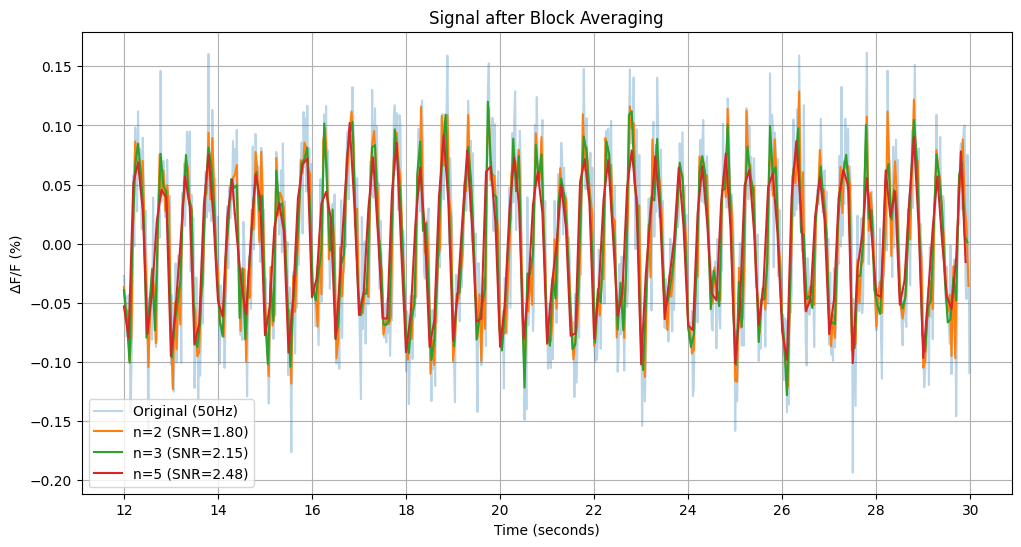

In [ ]:
def calc_snr(signal_samples, noise_samples):
    # compute signal and noise power (RMS based)
    S2 = np.mean(signal_samples**2)
    N2 = np.mean(noise_samples**2)

    # extract pure signal power by subtracting noise
    P_signal = S2 - N2
    P_signal = max(P_signal, 0)

    # compute SNR (avoid division by zero)
    return np.sqrt(P_signal / N2) if N2 > 0 else 0

def block_average(data, n):
    # trim data so it can be divided into equal blocks
    length = len(data) // n
    trimmed = data[:length * n]

    # reshape into blocks and average each block
    return trimmed.reshape(-1, n).mean(axis=1)

# compute original SNR
original_snr = calc_snr(stim_signal, noise_signal)

factors = [2, 3, 5]

plt.figure(figsize=(12, 6))

# time axis for original signal
time_orig = (np.arange(len(stim_signal)) / HZ) + 12
plt.plot(time_orig, stim_signal, alpha=0.3, label='Original (50Hz)')

for n in factors:

    # apply block averaging to signal and noise
    signal_avg = block_average(stim_signal, n)
    noise_avg = block_average(noise_signal, n)

    # compute SNR after averaging
    snr_new = calc_snr(signal_avg, noise_avg)

    # adjust time axis according to new sampling rate
    time_avg = np.arange(len(signal_avg)) * (n / HZ) + 12

    # plot averaged signal
    plt.plot(time_avg, signal_avg, label=f'n={n} (SNR={snr_new:.2f})')

    print(f"After averaging every {n} points: SNR = {snr_new:.4f}")

plt.title("Signal after Block Averaging")
plt.xlabel("Time (seconds)")
plt.ylabel("ΔF/F (%)")
plt.legend()
plt.grid(True)
plt.xticks(np.arange(12, 31, 2))
plt.show()

**2.3 - Heavier averaging (n=20).** The same block-averaging approach with a much larger block, to see the smoothing/resolution trade-off more clearly:

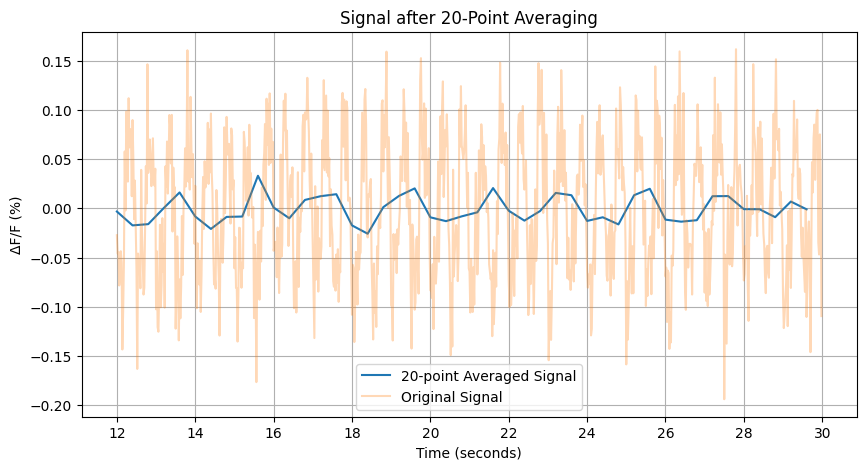

In [ ]:
n = 20

 # compute block averaged signal
signal_avg_20 = block_average(stim_signal, n)

# effective sampling rate after averaging
new_fs = HZ / n

# time axis for the downsampled signal
time_avg_20 = np.arange(len(signal_avg_20)) * (n / HZ) + 12

plt.figure(figsize=(10, 5))

# plot averaged smoothed signal
plt.plot(time_avg_20, signal_avg_20, label='20-point Averaged Signal')

# original signal for comparison
time_orig = (np.arange(len(stim_signal)) / HZ) + 12
plt.plot(time_orig, stim_signal, alpha=0.3, label='Original Signal')

plt.title('Signal after 20-Point Averaging')
plt.xlabel('Time (seconds)')
plt.ylabel('ΔF/F (%)')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(12, 31, 2))

plt.show()

**2.4 - Rectangular (moving-average) smoothing, applied twice.** A length-3 rectangular kernel `[1,1,1]/3` convolved with the signal, then convolved again with its own output.

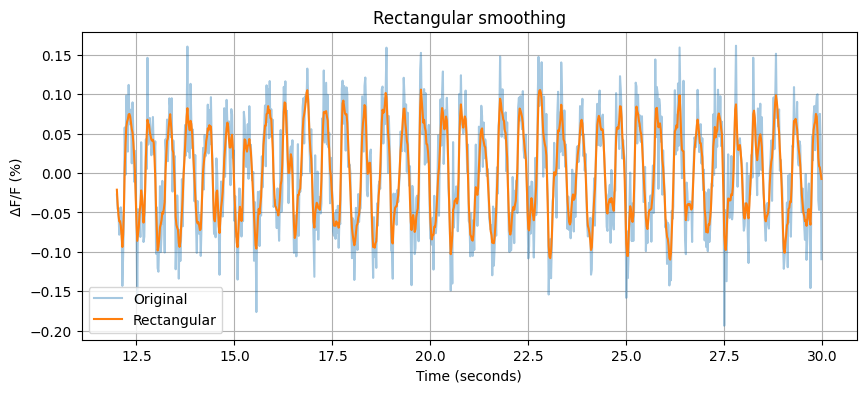

In [ ]:
# rectangular smoothing kernel
rect_kernel = np.ones(3)

# normalize kernel so sum = 1
rect_kernel = rect_kernel / np.sum(rect_kernel)

# first smoothing pass (moving average)
rect_once = np.convolve(stim_signal, rect_kernel, mode='same')

# second smoothing pass
rect_twice = np.convolve(rect_once, rect_kernel, mode='same')

plt.figure(figsize=(10,4))

plt.title("Rectangular smoothing")
plt.xlabel("Time (seconds)")
plt.ylabel("ΔF/F (%)")

# original noisy signal
plt.plot(time_stim, stim_signal, alpha=0.4, label="Original")

# twice-smoothed signal
plt.plot(time_stim, rect_twice, label="Rectangular")

plt.grid(True)
plt.legend()
plt.show()

**2.5 - Triangular smoothing (size 5).** A `[1,2,3,2,1]` kernel (normalized to sum to 1), which weights nearby samples more than distant ones - a softer version of the rectangular kernel.

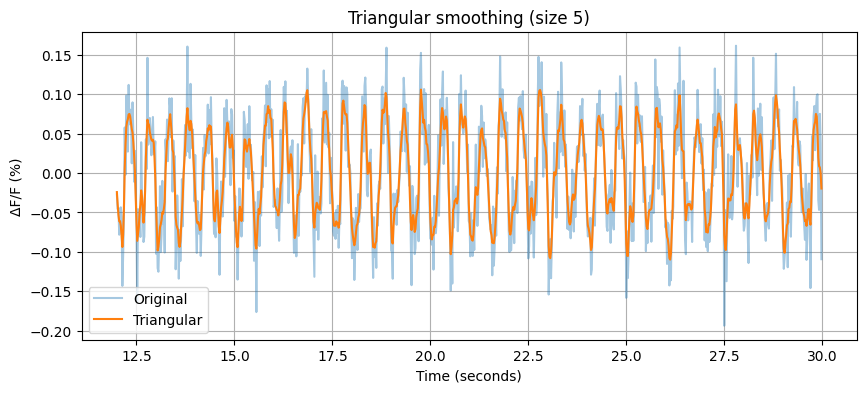

In [ ]:
# define triangular kernel (higher weight in center)
tri_kernel = np.array([1, 2, 3, 2, 1])

# normalize kernel so sum = 1
tri_kernel = tri_kernel / tri_kernel.sum()

# apply convolution for smoothing
tri_smoothed = np.convolve(stim_signal, tri_kernel, mode='same')

plt.figure(figsize=(10,4))

plt.title("Triangular smoothing (size 5)")
plt.xlabel("Time (seconds)")
plt.ylabel("ΔF/F (%)")

# original noisy signal
plt.plot(time_stim, stim_signal, alpha=0.4, label="Original")

# smoothed signal using triangular kernel
plt.plot(time_stim, tri_smoothed, label="Triangular")

plt.grid(True)
plt.legend()
plt.show()

**2.6 - Comparing the two smoothing methods.** Overlaying all three signals (original, double-rectangular, triangular) on one plot - the double-rectangular and triangular results turn out to be *identical*, since convolution is associative: convolving `[1,1,1]` with itself gives exactly `[1,2,3,2,1]`.

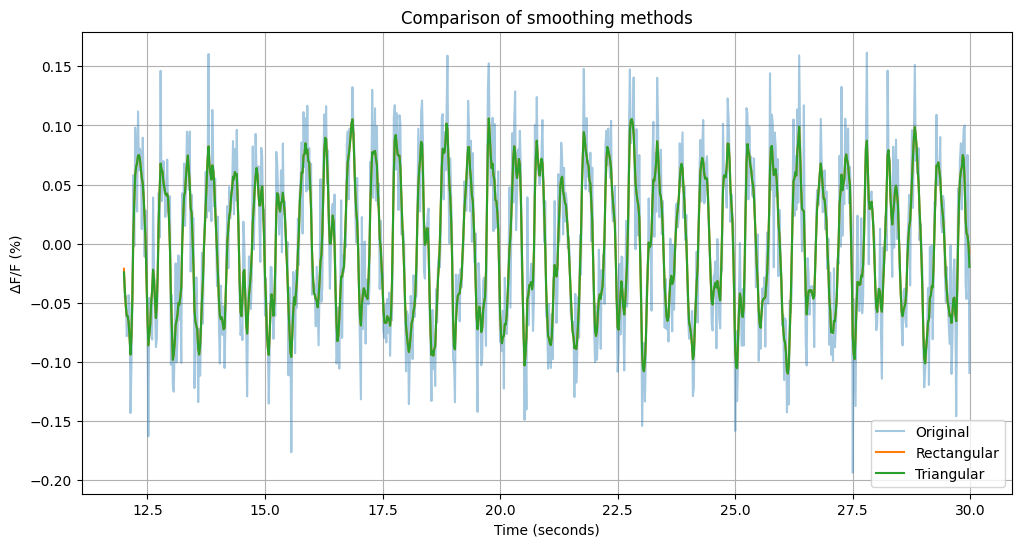

In [ ]:
plt.figure(figsize=(12,6))

plt.title("Comparison of smoothing methods")
plt.xlabel("Time (seconds)")
plt.ylabel("ΔF/F (%)")

# original noisy signal
plt.plot(time_stim, stim_signal, alpha=0.4, label="Original")

# rectangular smoothing result
plt.plot(time_stim, rect_twice, label="Rectangular")

# triangular smoothing result
plt.plot(time_stim, tri_smoothed, label="Triangular")

plt.grid(True)
plt.legend()
plt.show()

## Part 3 - Spike Train Analysis

Switching datasets: from here on, `spike_trains.csv` (5 neurons, A-E, 100 trials each, binary spike/no-spike per 1ms bin) is used instead of the continuous signal above.

**3.1.A - Mean firing rate.** Spikes are counted per trial and divided by trial duration (30s) to get each trial's firing rate in Hz, then averaged across all trials of each neuron.

In [ ]:
trial_duration_sec = 30

# extract neuron label (A-E)
df3['neuron'] = df3['trial_neuron'].str.extract(r'([A-E])', expand=False)

# count spikes in each trial and convert to firing rate (Hz)
df3['trial_fr'] = (df3.drop(columns=['trial_neuron', 'neuron']).sum(axis=1) / trial_duration_sec)

# compute mean firing rate across trials for each neuron
fr_results = (df3.groupby('neuron')['trial_fr'].mean().to_frame(name='Mean Firing Rate (Hz)'))

print(fr_results)

        Mean Firing Rate (Hz)
neuron                       
A                   11.670333
B                   42.550000
C                  100.000000
D                   49.984333
E                   28.679000


**3.1.B - Fano Factor** (variance/mean of the spike count in a fixed 1-second window across trials), per neuron - a measure of how regular vs. bursty each neuron's firing is.

In [ ]:
# take 1 second window (1000 samples)
spike_data = df3.iloc[:, 1:1001]

# count spikes per trial
df3['spike_count'] = spike_data.sum(axis=1)

# calculate FF per neuron
ff_results = df3.groupby('neuron')['spike_count'].agg(['mean', 'var'])

ff_results['Fano_Factor'] = ff_results['var'] / ff_results['mean']

print(ff_results['Fano_Factor'])

neuron
A    0.986133
B    0.574943
C    0.000000
D    0.010218
E    6.653800
Name: Fano_Factor, dtype: float64


**3.1.D - Inter-spike interval (ISI) distribution** for neurons A and B: the time gaps between consecutive spikes within each trial, pooled across all trials and shown as histograms.

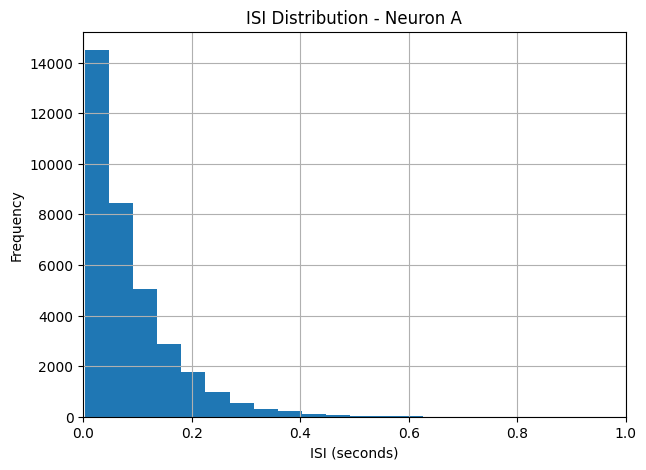

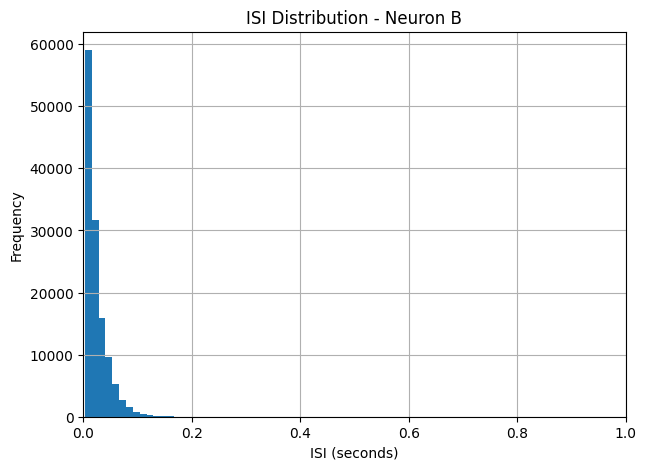

In [ ]:
new_HZ = 1000

# keep only spike columns
spike_data = df3.drop(columns=['trial_neuron','neuron','trial_fr','spike_count'])

# get trials of neuron A and B
neuron_A_trials = spike_data[df3['neuron'] == 'A'].values
neuron_B_trials = spike_data[df3['neuron'] == 'B'].values


# function to plot ISI distribution
def ISI_plot(data, title):

    all_distances = []

    # time per sample
    bin_size = 1 / new_HZ

    for trial in data:

        # indices where spike = 1
        spike_positions = [i for i, val in enumerate(trial) if val]
        # differences between consecutive spikes
        distances = np.diff(spike_positions)
        # convert from samples to seconds
        distances = distances * bin_size
        # add to list
        all_distances += list(distances)

    plt.figure(figsize=(7,5))

    plt.hist(all_distances, bins=20)

    plt.title(title)
    plt.xlabel('ISI (seconds)')
    plt.ylabel('Frequency')

    plt.xlim(0, 1)

    plt.grid(True)
    plt.show()


# plot neuron A
ISI_plot(neuron_A_trials, 'ISI Distribution - Neuron A')

# plot neuron B
ISI_plot(neuron_B_trials, 'ISI Distribution - Neuron B')

**3.1.E - Raster plots** for neurons A, C, D, E over the first second of recording: each row is one trial, each tick is a spike, making firing patterns (regular vs. random vs. bursty) visible at a glance.

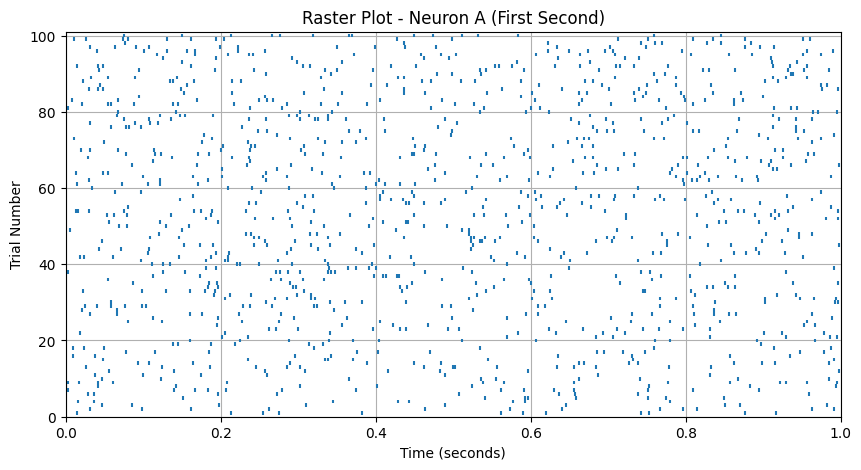

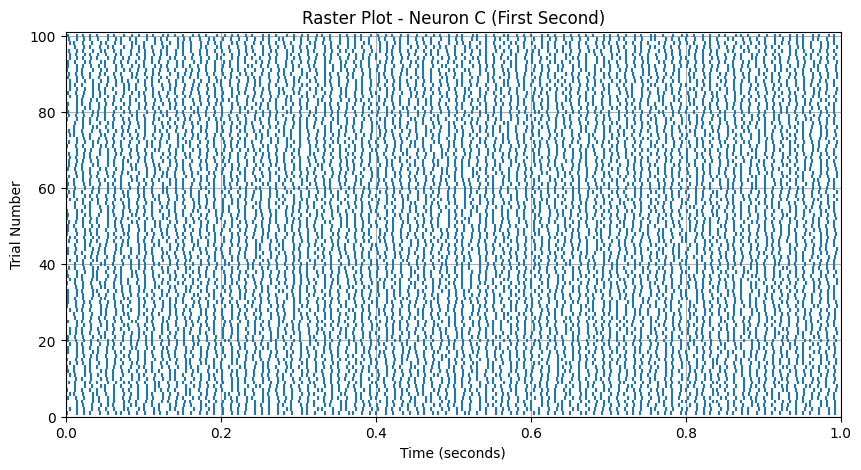

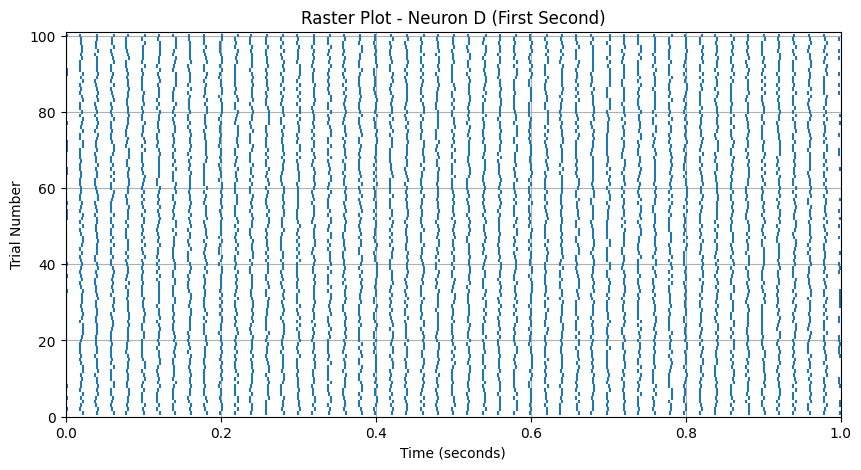

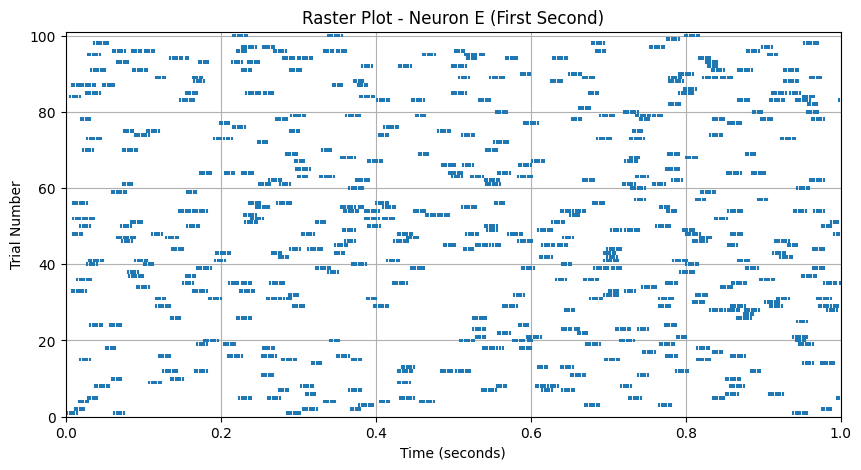

In [ ]:
neurons_to_plot = ['A', 'C', 'D', 'E']

for neuron in neurons_to_plot:

    # get trials of current neuron
    neuron_trials = spike_data[df3['neuron'] == neuron].values

    plt.figure(figsize=(10, 5))

    # go over all trials
    for trial_index, trial in enumerate(neuron_trials):

        # find spike locations
        spike_times = np.where(trial[:new_HZ] == 1)[0]

        # convert to seconds
        spike_times = spike_times / new_HZ

        # draw raster lines
        plt.vlines(spike_times, trial_index + 0.5, trial_index + 1.5)

    plt.title(f'Raster Plot - Neuron {neuron} (First Second)')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Trial Number')

    plt.xlim(0, 1)
    plt.ylim(0, len(neuron_trials) + 1)

    plt.grid(True)
    plt.show()

**3.1.G - PSTH (peri-stimulus time histogram)** for neurons A and D: spike times pooled across all 100 trials and binned into 200 x 5ms bins, normalized to a firing rate in Hz - this shows *when*, within the first second, each neuron tends to fire.

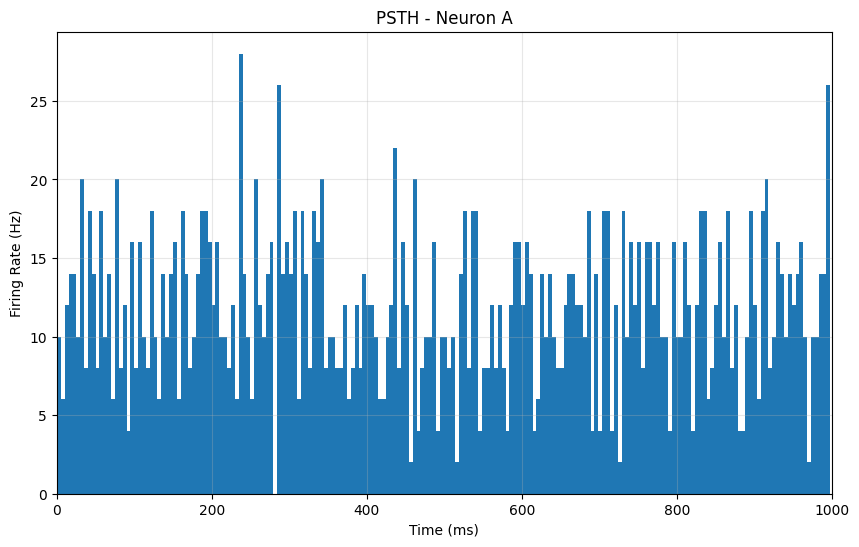

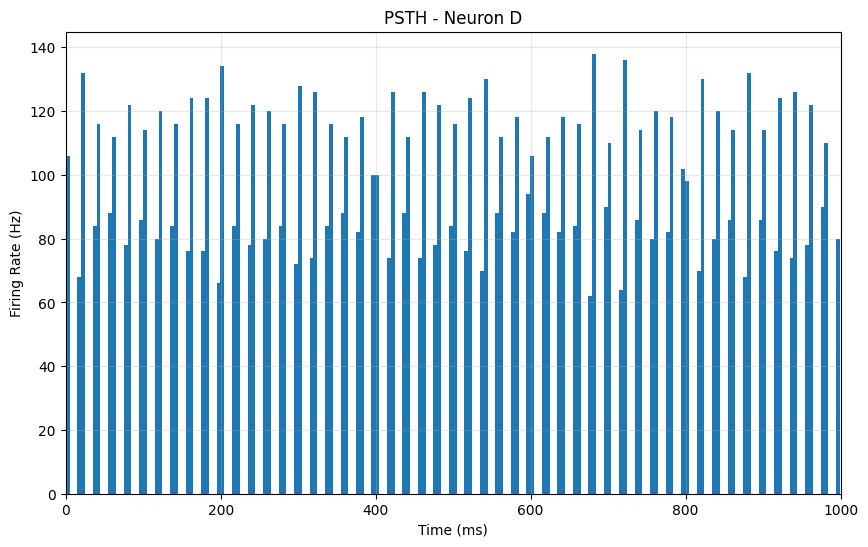

In [ ]:
# normalization settings
neurons_psth = ['A', 'D']
num_trials = 100
num_bins = 200

# bin width in seconds (5 ms)
bin_width_sec = (1000 / num_bins) / 1000

for neuron in neurons_psth:

    # get current neuron trials
    neuron_trials = spike_data[df3['neuron'] == neuron].values

    # keep only first second
    first_second = neuron_trials[:, :new_HZ]

    # collect spike times from all trials
    histogram_data = []

    for trial in first_second:
        spike_positions = np.where(trial == 1)[0]
        histogram_data += list(spike_positions)

    # normalize histogram to firing rate (Hz)
    weights = np.ones_like(histogram_data) / (num_trials * bin_width_sec)

    # plot normalized PSTH
    plt.figure(figsize=(10, 6))

    plt.hist(histogram_data, bins=num_bins, weights=weights, color='tab:blue', edgecolor='none')

    plt.title(f'PSTH - Neuron {neuron}')
    plt.xlabel('Time (ms)')
    plt.ylabel('Firing Rate (Hz)')

    plt.xlim(0, 1000)
    plt.grid(True, alpha=0.3)

    plt.show()

## Part 3.2 - Correlation Analysis

**3.2.A - Autocorrelation** for neurons A, C, D, E over the first 2 minutes: each neuron's spike train correlated with a time-shifted copy of itself, revealing periodicity (regular neurons) vs. flatness (Poisson-like) vs. a single sharp central peak (bursting).

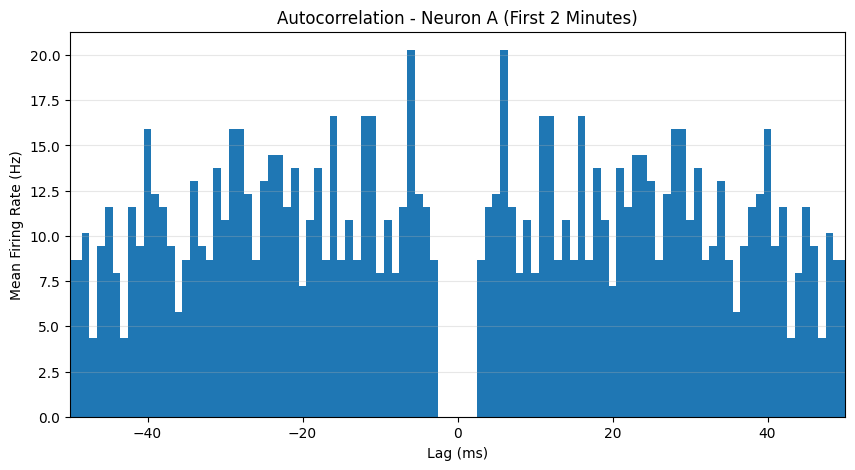

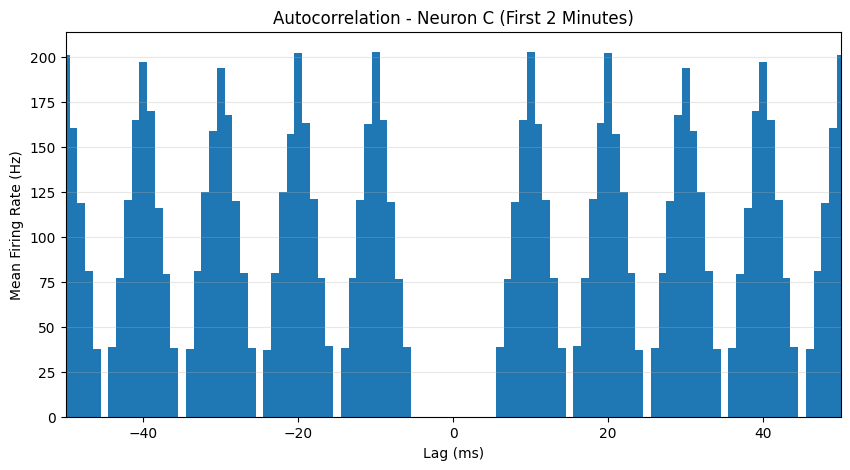

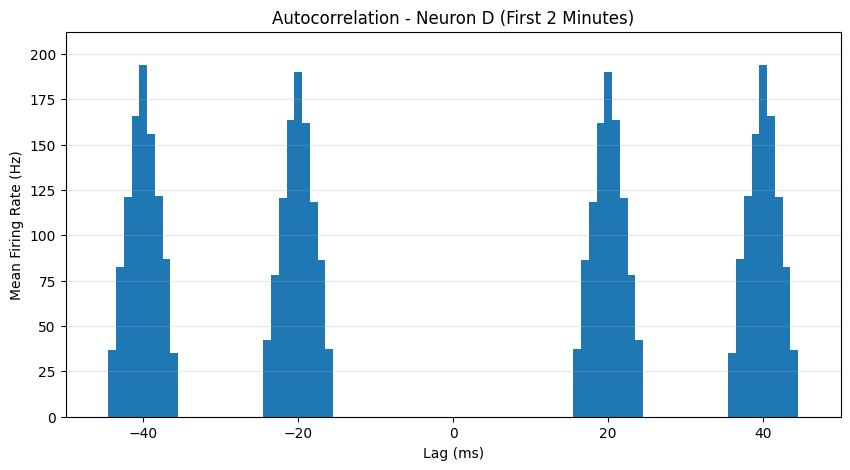

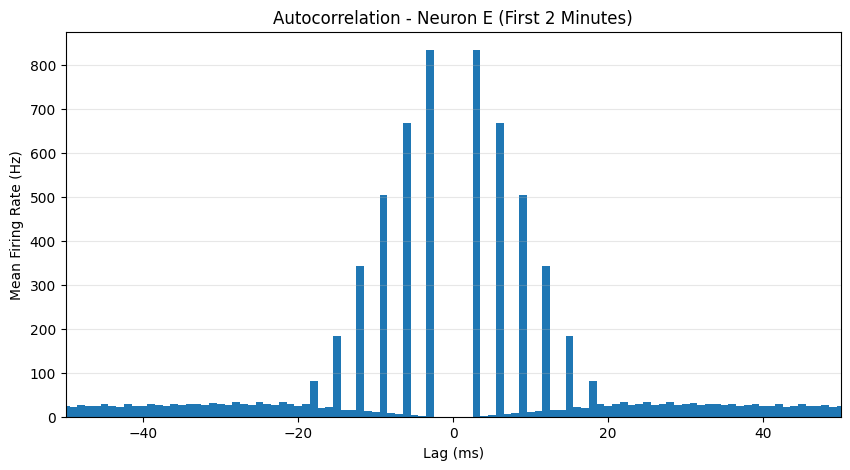

In [ ]:
duration_2_min_ms = 2 * 60 * 1000
max_lag_ms = 100

neurons_to_analyze = ['A', 'C', 'D', 'E']

for neuron_name in neurons_to_analyze:

    # get all trials of current neuron
    neuron_trials = spike_data[df3['neuron'] == neuron_name].values

    # concatenate trials into one long signal
    flattened_signal = neuron_trials.flatten()

    # keep first 2 minutes
    signal_segment = flattened_signal[:duration_2_min_ms]

    # compute autocorrelation
    corr = np.correlate(signal_segment, signal_segment, mode='full')

    mid_point = len(corr) // 2

    # create lag axis in ms
    lags = np.arange(-max_lag_ms, max_lag_ms + 1)

    # keep only small lag window around zero
    corr_segment = corr[
        mid_point - max_lag_ms : mid_point + max_lag_ms + 1
    ].astype(float)

    # normalize to mean firing rate
    num_spikes = np.sum(signal_segment)
    p_firing = corr_segment / num_spikes
    fr_hz = p_firing * new_HZ

    # remove self-correlation peak at lag 0
    fr_hz[max_lag_ms] = 0

    # plot autocorrelation
    plt.figure(figsize=(10, 5))

    plt.bar(lags, fr_hz, width=1, color='tab:blue')

    plt.title(f'Autocorrelation - Neuron {neuron_name} (First 2 Minutes)')
    plt.xlabel('Lag (ms)')
    plt.ylabel('Mean Firing Rate (Hz)')

    plt.xlim(-50, 50)
    plt.grid(axis='y', alpha=0.3)

    plt.show()

**3.2.E - Cross-correlation** between neuron pairs (A, B) and (C, D): looking for a lag at which one neuron's firing predicts the other's, as evidence of a (functional or synaptic) connection between them.

In [ ]:
def get_long_recording(neuron_label, data_df, limit_samples):

    # extract trials of selected neuron
    trials = data_df[data_df['neuron'] == neuron_label].drop(
        columns=['trial_neuron', 'neuron', 'trial_fr', 'spike_count'],
        errors='ignore').values

    # create one long spike train
    flattened = trials.flatten()

    return flattened[:limit_samples]

pairs = [('A', 'B'), ('C', 'D')]

for n1, n2 in pairs:

    # get 2-minute recordings
    sig1 = get_long_recording(n1, df3, duration_2_min_ms)
    sig2 = get_long_recording(n2, df3, duration_2_min_ms)

    # compute cross-correlation
    cc_full = np.correlate(sig2, sig1, mode='full')

    lags = np.arange(-(len(sig1) - 1), len(sig1))
    center_idx = len(cc_full) // 2

    # zoom around lag=0
    cc_zoom = cc_full[center_idx - max_lag_ms : center_idx + max_lag_ms + 1]

    lags_zoom = lags[center_idx - max_lag_ms : center_idx + max_lag_ms + 1]

    plt.figure(figsize=(10, 5))

    plt.bar(lags_zoom, cc_zoom, width=1, color='tab:blue',edgecolor='tab:blue')

    plt.title(f'Cross Correlation: Neuron {n1} vs Neuron {n2}')
    plt.xlabel('Lag (ms)')
    plt.ylabel('Correlation Count')

    # mark zero lag
    plt.axvline(0, color='red', linestyle='--', alpha=0.5)

    plt.grid(axis='y', alpha=0.3)
    plt.show()

**3.2.G - Normalized cross-correlation (C vs. D).** The same cross-correlation as above, but normalized by the reference neuron's spike count and bin width so the y-axis reads as a conditional firing rate in Hz rather than a raw correlation count.

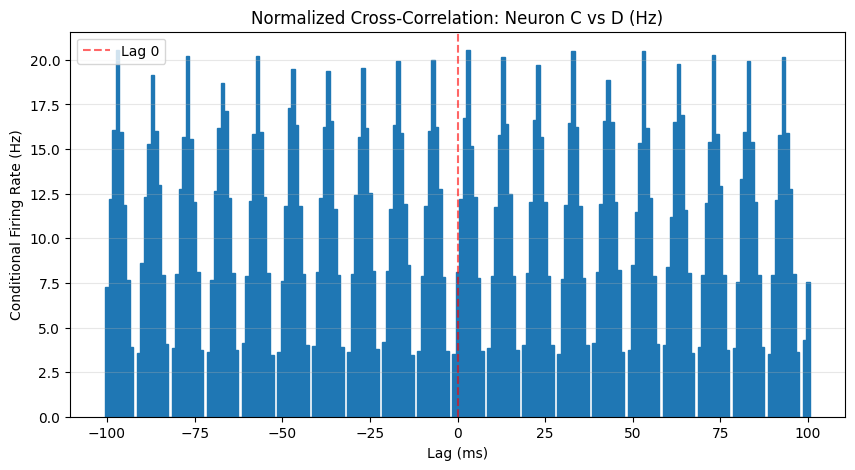

In [ ]:
n1, n2 = 'C', 'D'

# extract first 2 minutes of spike trains
sig1 = get_long_recording(n1, df3, duration_2_min_ms)
sig2 = get_long_recording(n2, df3, duration_2_min_ms)

# raw cross-correlation (unnormalized)
cc_raw = np.correlate(sig1, sig2, mode='full')

# number of spikes in reference neuron (normalization factor)
n_spikes_source = np.sum(sig1)

# convert correlation to conditional firing rate (Hz)
cc_normalized = (cc_raw / n_spikes_source) / bin_width_sec

# create lag axis
lags = np.arange(-(len(sig1) - 1), len(sig1))
center_idx = len(cc_raw) // 2

# zoom around zero lag
cc_zoom = cc_normalized[center_idx - max_lag_ms : center_idx + max_lag_ms + 1]
lags_zoom = lags[center_idx - max_lag_ms : center_idx + max_lag_ms + 1]

# plot result
plt.figure(figsize=(10, 5))
plt.bar(lags_zoom, cc_zoom, width=1, color='tab:blue', edgecolor='tab:blue')

plt.title(f'Normalized Cross-Correlation: Neuron {n1} vs {n2} (Hz)')
plt.xlabel('Lag (ms)')
plt.ylabel('Conditional Firing Rate (Hz)')

# mark zero lag
plt.axvline(0, color='red', linestyle='--', alpha=0.6, label='Lag 0')

plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

## Key Findings

**Part 1 - Sampling & quantization**
- Downsampling to 25 Hz or 10 Hz preserves a 2 Hz test signal correctly (Nyquist satisfied:
  fs > 2 x f_signal). Downsampling to ~3.33 Hz violates Nyquist (3.33 Hz < 4 Hz) and the 2 Hz
  signal aliases down to an apparent **1.33 Hz**.
- Resolving a 0.1% amplitude change requires at least **10 bits** of quantization.

**Part 2 - Noise reduction**
- The power-subtraction SNR method gives a stable positive value (~1.34); the amplitude-ratio
  method gives a near-zero/negative value on this oscillating signal, since positive and
  negative swings cancel in a simple mean - power-based SNR is the reliable one here.
- Block-averaging SNR improves monotonically with block size: **n=2 -> 1.80, n=3 -> 2.15,
  n=5 -> 2.48**, at the cost of time resolution.
- Two passes of a length-3 rectangular kernel produce a result **identical** to one pass of
  the `[1,2,3,2,1]` triangular kernel - a direct consequence of convolution's associativity
  (`[1,1,1] * [1,1,1] = [1,2,3,2,1]`).

**Part 3 - Spike train characterization**

| Neuron | Fano Factor | Firing pattern |
|---|---|---|
| A | ~0.99 | Poisson-like (random, FF close to 1) |
| B | ~0.57 | Below-Poisson variability, fairly regular |
| C | ~0.00 | Almost perfectly regular/periodic |
| D | ~0.01 | Regular/periodic, slightly less precise than C |
| E | ~6.65 | Bursting (dense spike clusters + quiet gaps) |

These are confirmed independently by the raster plots (regular vertical banding for C/D,
scattered for A, clustered bursts for E) and the autocorrelations (periodic peaks for C/D,
flat for A, one sharp central peak for E).

**Cross-correlation:** neurons A and B show a clear positive peak at a small positive lag
(~3 ms), consistent with A exciting B shortly after firing (a possible synaptic link).
Neurons C and D instead show a train of *periodic* peaks with no single dominant lag -
more consistent with both neurons responding to a shared periodic input than with a direct
connection between them.
